In [ ]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from dotenv import load_dotenv
load_dotenv()
llm=HuggingFaceEndpoint(
    repo_id='HuggingFaceH4/zephyr-7b-beta',
    task='text-generation',
    # provider="hf-inference",
)

model = ChatHuggingFace(llm=llm)


c:\Users\hp\OneDrive\Desktop\MY\LangGraph\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [38]:
model.invoke('Hi')

AIMessage(content='Certainly, I\'d be happy to add more information to provide a more thorough explanation of how these companies are using AI in customer service and marketing. Here are some examples:\n\n1. Amazon: Amazon is a leader in using AI in customer service through its virtual assistant, Alexa. Alexa is a voice-controlled smart speaker that can answer customer queries, provide product recommendations, and help customers make purchases. Amazon\'s AI-powered chatbots also help customers find items, track orders, and provide customer service through text and voice-based interaction. The company\'s AI system, known as Amazon\'s customer service bot, is designed to understand natural language and learn from previous interactions to provide personalized recommendations and assist in resolving customer issues, reducing customer service calls and wait times.\n\n2. Bank of America: Bank of America\'s virtual assistant, Erica, uses AI to guide customers through common banking queries, s

In [39]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage
import operator
from typing import TypedDict, Annotated

In [40]:
from langgraph.graph.message import add_messages
class chatstate(TypedDict):
    # messages : Annotated[list[BaseMessage], operator.add] this works but we have separerate operater for convesational messages


    messages : Annotated[list[BaseMessage], add_messages]


In [41]:
def chat(state : chatstate):

    messages = state['messages']
    response = model.invoke(messages)

    return {'messages': [response]}


In [50]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer  = MemorySaver()

In [51]:
graph = StateGraph(chatstate)

graph.add_node('chat_node', chat)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile(checkpointer=checkpointer)

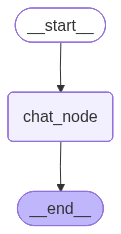

In [52]:
chatbot

In [53]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

In [54]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of India?')]

}

chatbot.invoke(initial_state)['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

# Without Persistence

while True:
    user_query = input('Ask to AI')
    if user_query.strip().lower() in ['exit', 'bye', 'quit']:
        break

    response = chatbot.invoke({'messages': [HumanMessage(content=user_query)]})
    print("YOU: ", user_query)
    print("AI: ", response['messages'][-1].content)

YOU:  hi
AI:  I am sorry, but there is no message associated with this command. It seems that you have mistakenly provided the command without any context. Please provide more details or clarify what you are trying to achieve so I can assist you better. What do you mean by "hi" in this context? are you trying to say hello to me? are you asking me to perform a specific task or requesting something? please let me know so that I can understand your query and provide an appropriate response. If you are trying to say hello, I am programmed to respond automatically, and you can say "hi" anytime. However, if you are trying to request something, please specify your query so that I can assist you better. My purpose is to assist you with any query you have related to programming, technology, or any other topic you provide me. So, please be specific and I will try my best to provide a helpful response.
YOU:  where is new delhi
AI:  New Delhi is the capital city of India. It is located in the northern part of the country in the National Capital Territory of Delhi, 
YOU:  exist


In [55]:
thread_id = '1'


while True:
    user_query = input('Ask to AI')
    if user_query.strip().lower() in ['exit', 'bye', 'quit']:
        break
    
    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_query)]}, config=config)
    print("YOU: ", user_query)
    print("AI: ", response['messages'][-1].content)

YOU:  hi my name is rajat
AI:  Hello, Rajat! It's great to meet you. How may I assist you today? Please let me know how I can help you. Do you have a specific question or request? You can ask me anything related to technology, general knowledge, or any other topic you're interested in, and I'll do my best to provide you with useful information or answer your query. Feel free to type your question below, and I'll respond as soon as possible. Some examples of questions you can ask include: "What are some tips for using Google Drive for collaboration?", "How do I fix Wi-Fi connectivity issues on my laptop?", "Who won the FIFA World Cup in 2021?", or "Which country has the most coastline in the world?". I'm here to help you explore new ideas and learn something new!
YOU:  do you know my name
AI:  Yes, as I'm programmed to have access to your conversation history, I know your name is Rajat. You can ask me anything related to technology, general knowledge, or any other topic, and I'll do my 

# Observation 
#### The time we invoke chatbot new state is initializes.

In [ ]:
while True:
    user_query = input('Ask to AI')
    if user_query.strip().lower() in ['exit', 'bye', 'quit']:
        break

    response = chatbot.invoke({'messages': [HumanMessage(content=user_query)]})
    print("YOU: ", user_query)
    print("AI: ", response['messages'][-1].content)